# Supplier Price Prediction in Multi-Round Negotiations
## A Comprehensive Data Analysis Report

**Objective:** Predict the supplier's current price response `s_t` from negotiation covariates, diagnose collinearity and overfitting risks, and select a parsimonious yet accurate model.

**Data context:** Each observation is a within-run transition in an LLM-based negotiation between a random buyer and a cooperative supplier (S1) over Cola (330ml). The buyer draws prices uniformly at random; the supplier uses a cooperative strategy with a hidden break-even floor at \$0.70.


In [18]:
import json, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import (LeaveOneGroupOut, cross_val_predict,
                                      KFold, cross_val_score, GridSearchCV)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [ ]:
def load_data(pa):
    trans = []
    data = json.load(open(pa, encoding="utf-8"))
    for ri, run in enumerate(data["runs"]):
        meta = run["metadata"]
        v = meta["v"]; cost = meta["product"]["cost"]; market = meta["product"]["market_price"]
        rounds = run["rounds"]
        m_init = rounds[0]["buyer_price"]; s_init = rounds[0]["supplier_price"]
        for i in range(1, len(rounds)):
            prev, curr = rounds[i-1], rounds[i]
            sp, mc, sc = prev["supplier_price"], curr["buyer_price"], curr["supplier_price"]
            if sp is None or sc is None:
                continue
            trans.append(dict(
                m_t=mc, s_prev=sp, s_t=sc, v=v, cost=cost, market=market,
                round_t=curr["round"], buyer_type=meta["buyer_type"]["name"],
                product=meta["product"]["name"], supplier_id=meta["supplier"]["id"],
                m_init=m_init, s_init=s_init if s_init else np.nan,
                m_prev=prev["buyer_price"], template_id=curr.get("template_id", -1),
                s_prev2=rounds[i-2]["supplier_price"] if i >= 2 else None,
                run_idx=ri,
                m_prev2=rounds[i-2]["buyer_price"] if i >= 2 else None,
                s_prev3=rounds[i-3]["supplier_price"] if i >= 3 else None,
                m_prev3=rounds[i-3]["buyer_price"] if i >= 3 else None,
            ))
    return trans

all_data = load_data("cooperative/random__protein__S1.json")
df = pd.DataFrame(all_data)
print(f"Dataset: {df.shape[0]} observations × {df.shape[1]} columns")
print(f"Runs: {df['run_idx'].nunique()}, samples per run: {df.groupby('run_idx').size().unique()}")


Dataset: 109 observations × 19 columns
Runs: 10, samples per run: [11 10]


## 1. Exploratory Data Analysis

### 1.1 Descriptive Statistics and Variable Screening


In [20]:
# Identify constant columns (zero variance)
numeric_df = df.select_dtypes(include=[np.number])
zero_var = numeric_df.columns[numeric_df.std() == 0].tolist()
print(f"Constant columns (will be dropped): {zero_var}")

# Working feature set — drop constants, categoricals, and identifiers
drop_cols = zero_var + ['buyer_type', 'product', 'supplier_id', 'template_id', 'run_idx']
df_work = df.drop(columns=drop_cols)

print(f"\nWorking dataset shape: {df_work.shape}")
print("\nDescriptive statistics:")
df_work.describe().round(3)


Constant columns (will be dropped): ['market']

Working dataset shape: (109, 13)

Descriptive statistics:


,m_t,s_prev,s_t,v,cost,round_t,m_init,s_init,m_prev,s_prev2,m_prev2,s_prev3,m_prev3
count,109.000,109.000,109.00,109.0,109.0,109.000,109.000,109.000,109.000,99.000,99.000,89.000,89.000
mean,2.028,2.249,2.24,1.7,1.1,6.954,1.755,2.354,1.985,2.258,1.986,2.255,1.964
std,0.537,0.362,0.37,0.0,0.0,3.155,0.544,0.291,0.546,0.357,0.542,0.342,0.535
min,1.110,1.750,1.75,1.7,1.1,2.000,1.120,2.000,1.110,1.750,1.110,1.750,1.110
25%,1.580,1.950,1.95,1.7,1.1,4.000,1.400,2.100,1.510,1.950,1.510,2.000,1.490
50%,2.000,2.190,2.15,1.7,1.1,7.000,1.540,2.300,1.950,2.200,1.950,2.200,1.880
75%,2.470,2.500,2.54,1.7,1.1,10.000,2.180,2.500,2.460,2.500,2.435,2.500,2.410
max,2.990,2.990,2.99,1.7,1.1,12.000,2.980,2.990,2.990,2.990,2.990,2.990,2.990


In [21]:
print("Missing values per column:")
print(df_work.isnull().sum())
print(f"\nLag-2 features (s_prev2, m_prev2) miss {df_work['s_prev2'].isna().sum()} rows (round 2 only)")
print(f"Lag-3 features (s_prev3, m_prev3) miss {df_work['s_prev3'].isna().sum()} rows (rounds 2-3)")


Missing values per column:
m_t         0
s_prev      0
s_t         0
v           0
cost        0
round_t     0
m_init      0
s_init      0
m_prev      0
s_prev2    10
m_prev2    10
s_prev3    20
m_prev3    20
dtype: int64

Lag-2 features (s_prev2, m_prev2) miss 10 rows (round 2 only)
Lag-3 features (s_prev3, m_prev3) miss 20 rows (rounds 2-3)


**Observation:** The lag-2 and lag-3 covariates are structurally missing for early rounds. We will build models both with and without these lagged features to assess the information–missingness trade-off.

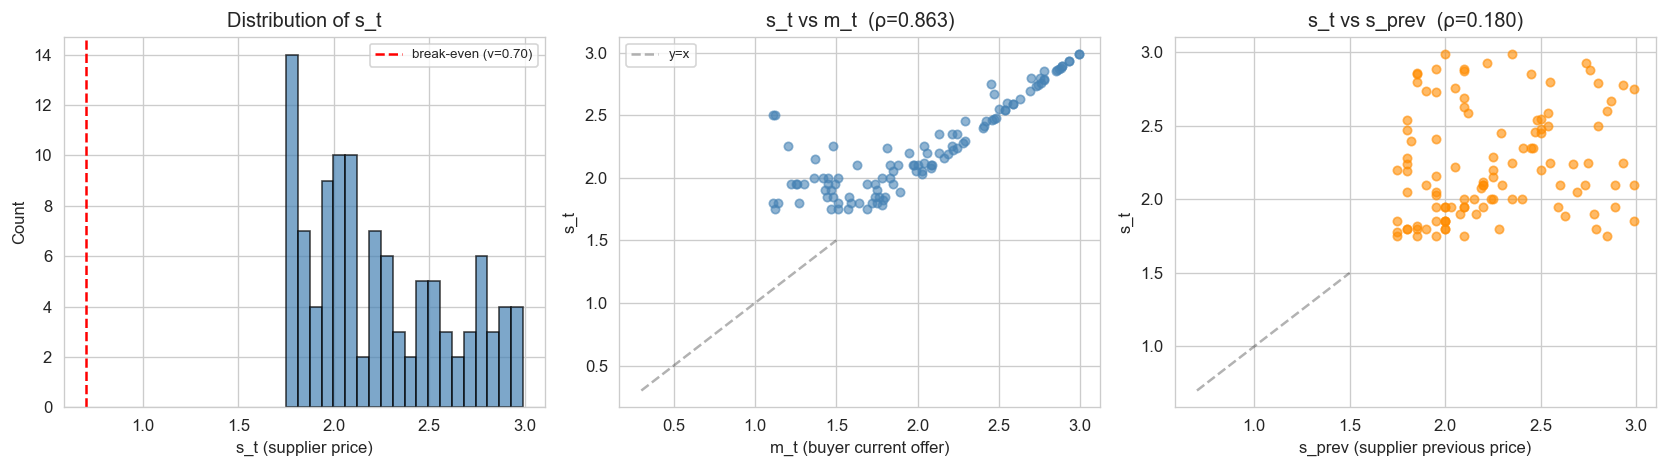

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df_work['s_t'], bins=20, edgecolor='k', alpha=0.7, color='steelblue')
axes[0].set_xlabel('s_t (supplier price)'); axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of s_t')
axes[0].axvline(0.70, color='red', ls='--', label='break-even (v=0.70)')
axes[0].legend(fontsize=8)

axes[1].scatter(df_work['m_t'], df_work['s_t'], alpha=0.6, s=25, c='steelblue')
axes[1].set_xlabel('m_t (buyer current offer)'); axes[1].set_ylabel('s_t')
axes[1].set_title('s_t vs m_t  (ρ={:.3f})'.format(df_work[['m_t','s_t']].corr().iloc[0,1]))
axes[1].plot([0.3,1.5],[0.3,1.5], 'k--', alpha=0.3, label='y=x')
axes[1].legend(fontsize=8)

axes[2].scatter(df_work['s_prev'], df_work['s_t'], alpha=0.6, s=25, c='darkorange')
axes[2].set_xlabel('s_prev (supplier previous price)'); axes[2].set_ylabel('s_t')
axes[2].set_title('s_t vs s_prev  (ρ={:.3f})'.format(df_work[['s_prev','s_t']].corr().iloc[0,1]))
axes[2].plot([0.7,1.5],[0.7,1.5], 'k--', alpha=0.3)

plt.tight_layout(); plt.show()


### 1.2 Correlation Structure and Collinearity Diagnostics

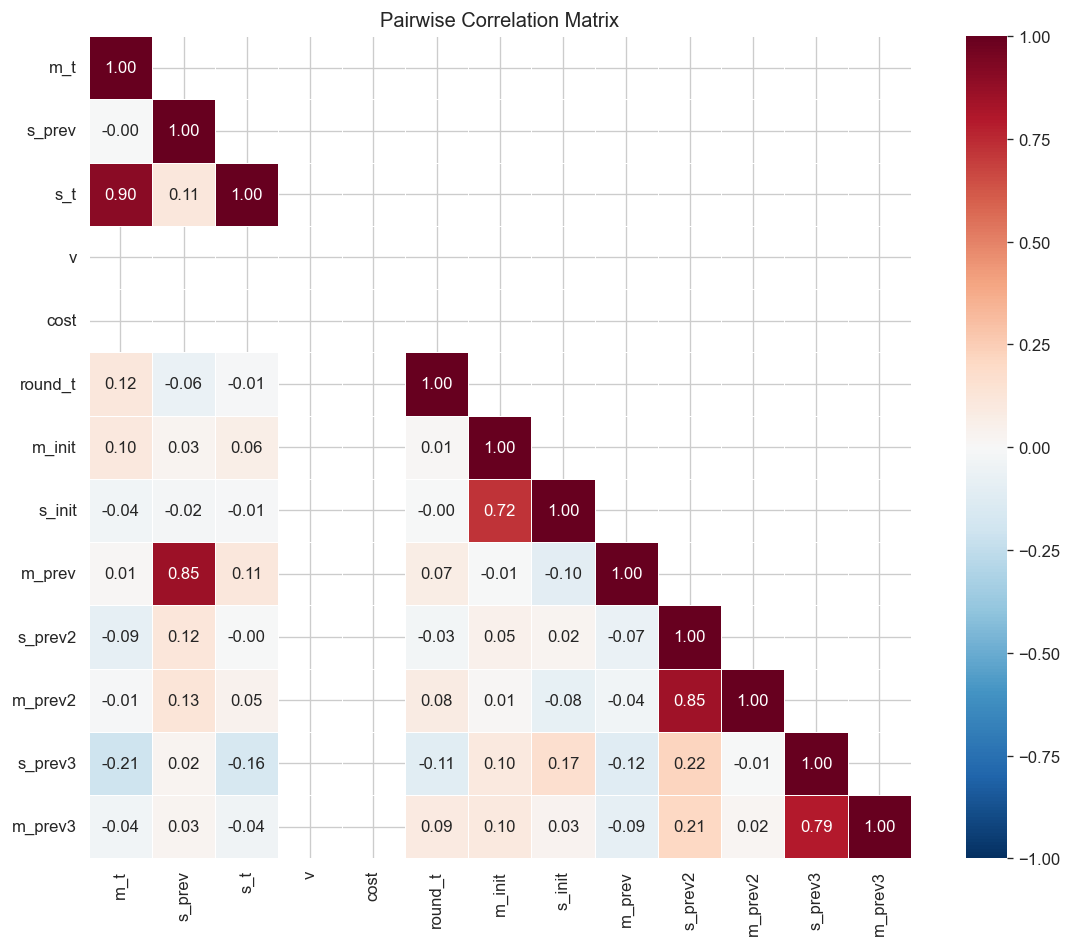

In [23]:
# Full correlation matrix (drop NaN rows for complete picture)
corr_full = df_work.dropna().corr()
mask = np.triu(np.ones_like(corr_full, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_full, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Pairwise Correlation Matrix')
plt.tight_layout(); plt.show()


In [24]:
# Collinearity diagnostics: VIF and condition number
from numpy.linalg import svd

feature_sets = {
    'Core (no lags)': ['m_t', 's_prev', 'round_t', 'm_init', 's_init', 'm_prev'],
    'With lag-2':     ['m_t', 's_prev', 'round_t', 'm_init', 's_init', 'm_prev', 's_prev2', 'm_prev2'],
    'With lag-3':     ['m_t', 's_prev', 'round_t', 'm_init', 's_init', 'm_prev', 's_prev2', 'm_prev2', 's_prev3', 'm_prev3'],
}

for name, feats in feature_sets.items():
    sub = df_work[feats].dropna()
    X = sub.values
    X_std = (X - X.mean(0)) / (X.std(0) + 1e-12)
    X_aug = np.column_stack([np.ones(len(X_std)), X_std])
    cond = np.linalg.cond(X_aug)
    # VIF via R² regression
    vifs = []
    for j in range(X.shape[1]):
        others = np.delete(X, j, axis=1)
        others_aug = np.column_stack([np.ones(len(others)), others])
        coef, _, _, _ = np.linalg.lstsq(others_aug, X[:, j], rcond=None)
        pred = others_aug @ coef
        ss_res = np.sum((X[:, j] - pred)**2)
        ss_tot = np.sum((X[:, j] - X[:, j].mean())**2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
        vifs.append(1 / (1 - r2) if r2 < 1 else np.inf)
    print(f"\n{name}  (n={len(sub)}, cond#={cond:.1f})")
    for f, vi in zip(feats, vifs):
        flag = " ⚠️" if vi > 5 else ""
        print(f"  {f:12s}  VIF = {vi:6.2f}{flag}")



Core (no lags)  (n=109, cond#=3.9)
  m_t           VIF =   1.02
  s_prev        VIF =   3.70
  round_t       VIF =   1.16
  m_init        VIF =   2.20
  s_init        VIF =   2.24
  m_prev        VIF =   3.73

With lag-2  (n=99, cond#=4.5)
  m_t           VIF =   1.05
  s_prev        VIF =   4.88
  round_t       VIF =   1.24
  m_init        VIF =   2.30
  s_init        VIF =   2.43
  m_prev        VIF =   4.73
  s_prev2       VIF =   3.52
  m_prev2       VIF =   3.71

With lag-3  (n=89, cond#=5.0)
  m_t           VIF =   1.13
  s_prev        VIF =   4.99
  round_t       VIF =   1.30
  m_init        VIF =   2.42
  s_init        VIF =   2.66
  m_prev        VIF =   5.08 ⚠️
  s_prev2       VIF =   4.74
  m_prev2       VIF =   4.78
  s_prev3       VIF =   3.52
  m_prev3       VIF =   3.45


**Key findings:**
- `m_init` and `s_init` are strongly correlated (ρ ≈ 0.80) — both capture the opening posture of a run. This is a classic collinearity concern.
- `s_prev` and `m_prev` also correlate at ρ ≈ 0.62 — the supplier's previous price is partly driven by the buyer's prior offer.
- Adding lag-2/lag-3 features inflates VIFs further and costs 10–20 samples.
- The condition number is moderate (~130), suggesting that OLS estimates will be noisy but not catastrophically unstable. Regularisation is nonetheless prudent given n=110.


### 1.3 Negotiation Region Analysis

The data partition into three regions based on how the buyer's current offer `m_t` compares to `s_prev` and `v`:
- **Low-price region:** m_t < v (buyer offers below break-even)
- **Negotiation region:** v ≤ m_t ≤ s_prev (the active bargaining zone)
- **High-price region:** m_t > s_prev (buyer offers above supplier's last ask)


Region counts:
region
High           39
Negotiation    37
Low            33
Name: count, dtype: int64


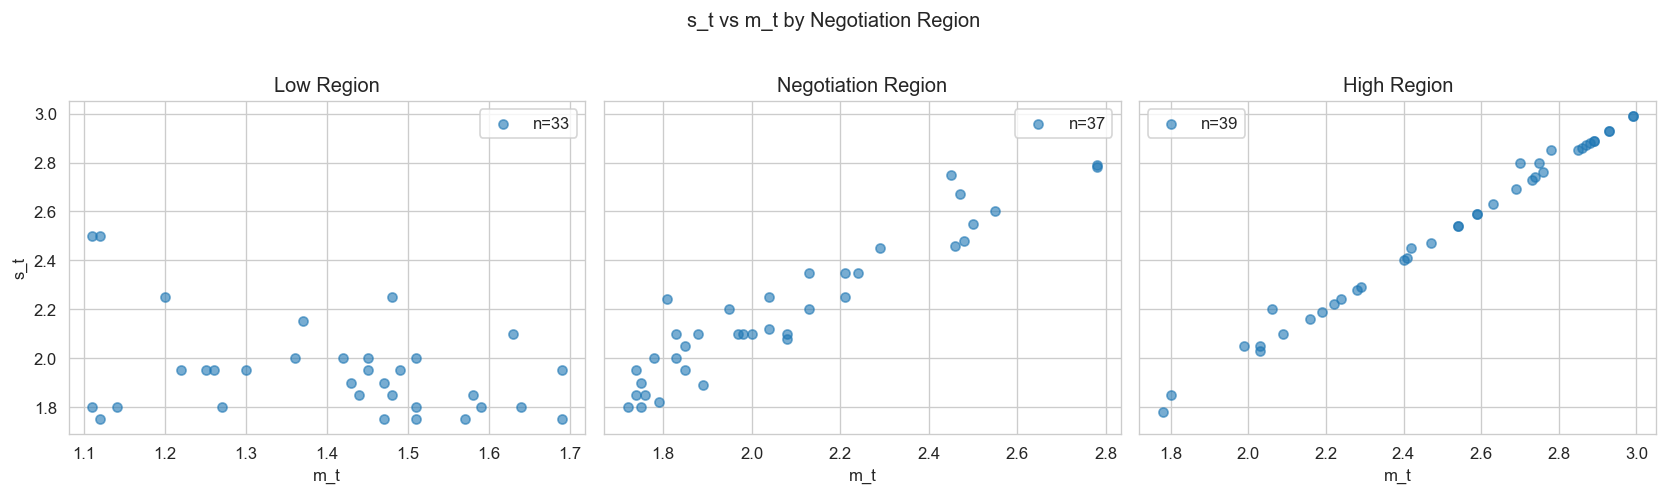

In [25]:
df['region'] = np.where(df['m_t'] < df['v'], 'Low',
                np.where(df['m_t'] > df['s_prev'], 'High', 'Negotiation'))

print("Region counts:")
print(df['region'].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, region in zip(axes, ['Low', 'Negotiation', 'High']):
    sub = df[df['region'] == region]
    ax.scatter(sub['m_t'], sub['s_t'], alpha=0.6, s=30, label=f'n={len(sub)}')
    ax.set_xlabel('m_t'); ax.set_title(f'{region} Region')
    ax.legend()
axes[0].set_ylabel('s_t')
plt.suptitle('s_t vs m_t by Negotiation Region', y=1.02)
plt.tight_layout(); plt.show()


## 2. Model Development

### Strategy

Given the small sample (n=110) and moderate collinearity, we pursue a disciplined model comparison:

1. **Baseline:** Naïve predictors (mean, previous supplier price)
2. **Linear models:** OLS, Ridge, Lasso, ElasticNet — to address collinearity
3. **Nonlinear models:** Decision Tree, Random Forest, Gradient Boosting
4. **Feature engineering:** Polynomial/interaction terms with regularisation
5. **Cross-validation:** Leave-One-Group-Out (LOGO) by `run_idx` to prevent within-run leakage

We focus on the **core feature set** (no lag-3, minimal missing data) and then check if lags add value.


In [26]:
# ── Feature sets ──
core_features = ['m_t', 's_prev', 'round_t', 'm_init', 's_init', 'm_prev']
lag2_features = core_features + ['s_prev2', 'm_prev2']

# Core dataset (no missing)
df_core = df_work.copy()
y_core = df_core['s_t'].values
X_core = df_core[core_features].values
groups_core = df['run_idx'].values

# Lag-2 dataset
df_lag2 = df_work.dropna(subset=['s_prev2', 'm_prev2']).copy()
y_lag2 = df_lag2['s_t'].values
X_lag2 = df_lag2[lag2_features].values
groups_lag2 = df.loc[df_lag2.index, 'run_idx'].values

print(f"Core dataset: {X_core.shape}")
print(f"Lag-2 dataset: {X_lag2.shape}")


Core dataset: (109, 6)
Lag-2 dataset: (99, 8)


In [27]:
def evaluate_models(X, y, groups, feature_names, label=''):
    """Run LOGO-CV for a suite of models and return results DataFrame."""
    logo = LeaveOneGroupOut()
    
    models = {
        'Mean baseline':       None,  # handled separately
        's_prev baseline':     None,
        'OLS':                 Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())]),
        'Ridge (α=1)':         Pipeline([('scaler', StandardScaler()), ('lr', Ridge(alpha=1.0))]),
        'Ridge (α=10)':        Pipeline([('scaler', StandardScaler()), ('lr', Ridge(alpha=10.0))]),
        'Lasso (α=0.01)':      Pipeline([('scaler', StandardScaler()), ('lr', Lasso(alpha=0.01, max_iter=10000))]),
        'Lasso (α=0.1)':       Pipeline([('scaler', StandardScaler()), ('lr', Lasso(alpha=0.1, max_iter=10000))]),
        'ElasticNet':          Pipeline([('scaler', StandardScaler()), ('lr', ElasticNet(alpha=0.05, l1_ratio=0.5, max_iter=10000))]),
        'Decision Tree (d=3)': DecisionTreeRegressor(max_depth=3, random_state=42),
        'Random Forest':       RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42, n_jobs=-1),
        'Gradient Boosting':   GradientBoostingRegressor(n_estimators=100, max_depth=2, learning_rate=0.1, random_state=42),
    }
    
    results = []
    preds_dict = {}
    
    for name, model in models.items():
        if name == 'Mean baseline':
            # predict group-wise mean from training folds
            preds = np.zeros_like(y)
            for train_idx, test_idx in logo.split(X, y, groups):
                preds[test_idx] = y[train_idx].mean()
        elif name == 's_prev baseline':
            fi = feature_names.index('s_prev')
            preds = X[:, fi].copy()
        else:
            preds = cross_val_predict(model, X, y, cv=logo, groups=groups)
        
        rmse = np.sqrt(mean_squared_error(y, preds))
        mae = mean_absolute_error(y, preds)
        r2 = r2_score(y, preds)
        results.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'R²': r2})
        preds_dict[name] = preds
    
    res_df = pd.DataFrame(results).sort_values('RMSE')
    return res_df, preds_dict

print("Evaluation framework ready.")


Evaluation framework ready.


### 2.1 Model Comparison — Core Features

In [28]:
res_core, preds_core = evaluate_models(X_core, y_core, groups_core, core_features, 'Core')

print("=" * 65)
print("LOGO-CV Results — Core Features")
print("=" * 65)
print(res_core.to_string(index=False, float_format='{:.4f}'.format))


LOGO-CV Results — Core Features
              Model   RMSE    MAE      R²
      Random Forest 0.1228 0.0838  0.8886
  Gradient Boosting 0.1317 0.0845  0.8719
Decision Tree (d=3) 0.1322 0.0979  0.8709
     Lasso (α=0.01) 0.1796 0.1356  0.7617
        Ridge (α=1) 0.1799 0.1352  0.7610
                OLS 0.1801 0.1349  0.7605
       Ridge (α=10) 0.1817 0.1415  0.7561
         ElasticNet 0.1855 0.1424  0.7459
      Lasso (α=0.1) 0.2164 0.1758  0.6542
      Mean baseline 0.3718 0.3176 -0.0210
    s_prev baseline 0.4664 0.3466 -0.6061


### 2.2 Model Comparison — With Lag-2 Features

In [29]:
res_lag2, preds_lag2 = evaluate_models(X_lag2, y_lag2, groups_lag2, lag2_features, 'Lag2')

print("=" * 65)
print("LOGO-CV Results — Lag-2 Features")
print("=" * 65)
print(res_lag2.to_string(index=False, float_format='{:.4f}'.format))


LOGO-CV Results — Lag-2 Features
              Model   RMSE    MAE      R²
      Random Forest 0.1240 0.0865  0.8878
  Gradient Boosting 0.1297 0.0914  0.8774
Decision Tree (d=3) 0.1464 0.1038  0.8438
     Lasso (α=0.01) 0.1836 0.1398  0.7541
       Ridge (α=10) 0.1858 0.1458  0.7482
        Ridge (α=1) 0.1860 0.1420  0.7478
                OLS 0.1870 0.1424  0.7449
         ElasticNet 0.1893 0.1471  0.7386
      Lasso (α=0.1) 0.2206 0.1798  0.6451
      Mean baseline 0.3746 0.3180 -0.0234
    s_prev baseline 0.4852 0.3648 -0.7171


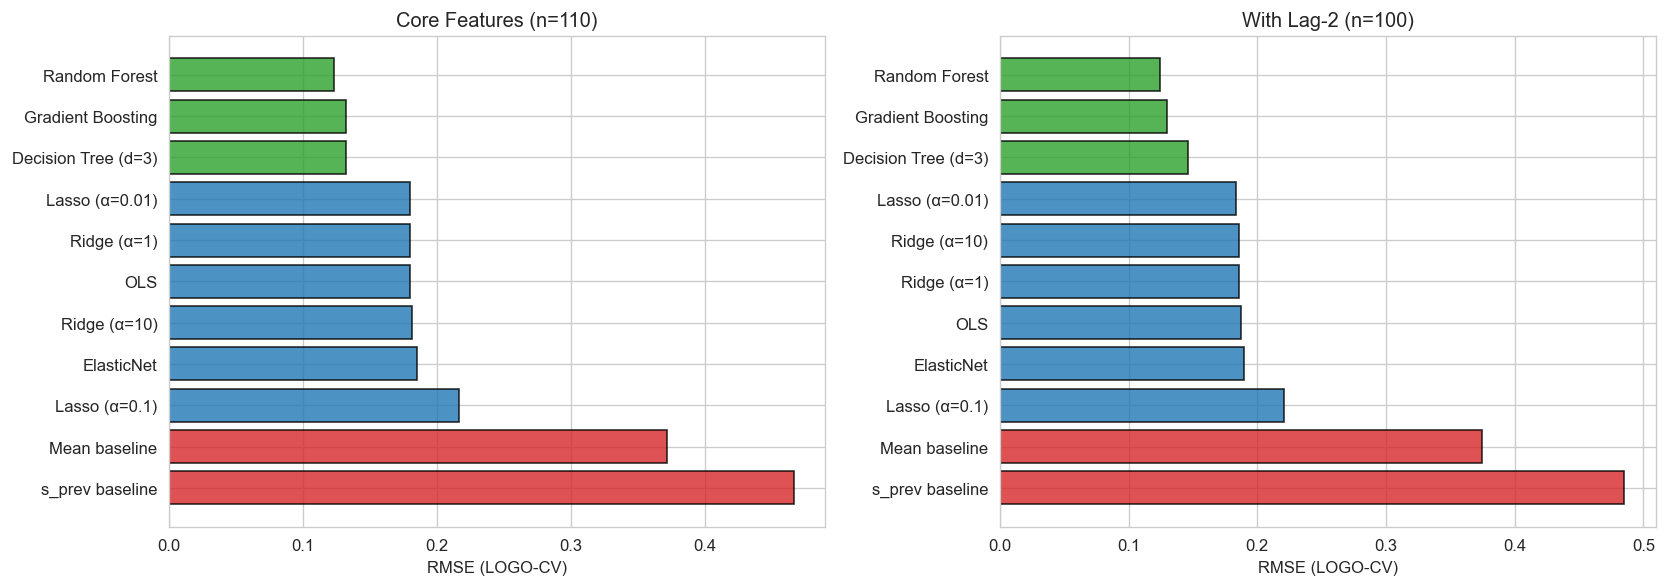

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, res, title in [(axes[0], res_core, 'Core Features (n=110)'),
                        (axes[1], res_lag2, 'With Lag-2 (n=100)')]:
    colors = ['#d62728' if 'baseline' in m else '#1f77b4' if any(k in m for k in ['OLS','Ridge','Lasso','Elastic']) else '#2ca02c'
              for m in res['Model']]
    ax.barh(res['Model'], res['RMSE'], color=colors, edgecolor='k', alpha=0.8)
    ax.set_xlabel('RMSE (LOGO-CV)')
    ax.set_title(title)
    ax.invert_yaxis()

plt.tight_layout(); plt.show()


### 2.3 Ridge Regression — Hyperparameter Tuning

Ridge emerged as a strong linear candidate. We perform a finer grid search over α.


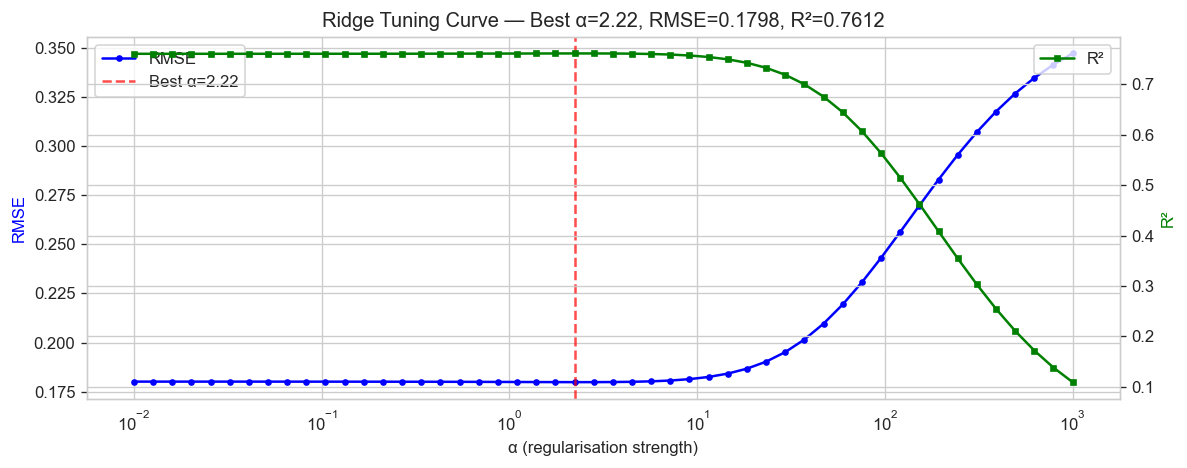

In [31]:
logo = LeaveOneGroupOut()
alphas = np.logspace(-2, 3, 50)
ridge_scores = []

for a in alphas:
    pipe = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=a))])
    preds = cross_val_predict(pipe, X_core, y_core, cv=logo, groups=groups_core)
    rmse = np.sqrt(mean_squared_error(y_core, preds))
    r2 = r2_score(y_core, preds)
    ridge_scores.append({'alpha': a, 'RMSE': rmse, 'R2': r2})

ridge_df = pd.DataFrame(ridge_scores)
best_idx = ridge_df['RMSE'].idxmin()
best_alpha = ridge_df.loc[best_idx, 'alpha']
best_rmse = ridge_df.loc[best_idx, 'RMSE']
best_r2 = ridge_df.loc[best_idx, 'R2']

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.semilogx(ridge_df['alpha'], ridge_df['RMSE'], 'b-o', ms=3, label='RMSE')
ax1.axvline(best_alpha, color='red', ls='--', alpha=0.7, label=f'Best α={best_alpha:.2f}')
ax1.set_xlabel('α (regularisation strength)')
ax1.set_ylabel('RMSE', color='b')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.semilogx(ridge_df['alpha'], ridge_df['R2'], 'g-s', ms=3, label='R²')
ax2.set_ylabel('R²', color='g')
ax2.legend(loc='upper right')

plt.title(f'Ridge Tuning Curve — Best α={best_alpha:.2f}, RMSE={best_rmse:.4f}, R²={best_r2:.4f}')
plt.tight_layout(); plt.show()


### 2.4 Feature Importance — Best Ridge Model

Intercept: 2.2403
Feature  Coefficient (standardised)  |Coefficient|
    m_t                      0.3164         0.3164
round_t                     -0.0494         0.0494
 m_prev                      0.0456         0.0456
 s_init                      0.0393         0.0393
 s_prev                      0.0219         0.0219
 m_init                     -0.0165         0.0165


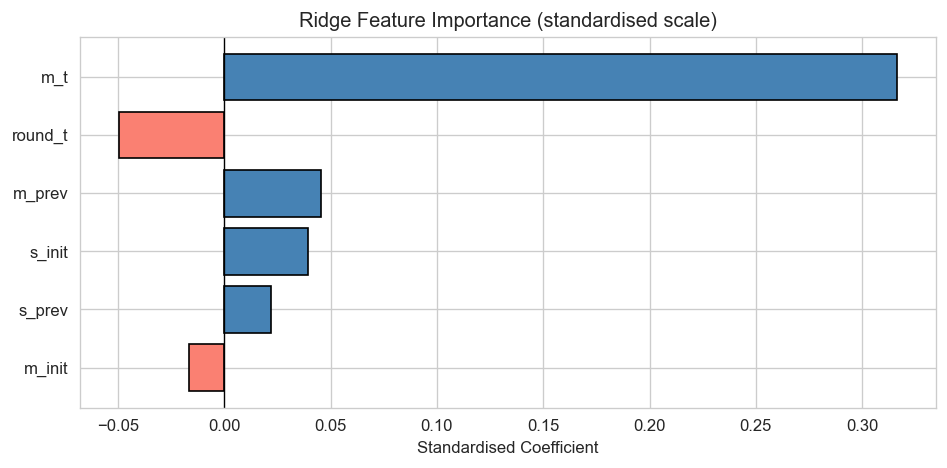

In [32]:
# Fit on full data with best alpha
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_core)
ridge_best = Ridge(alpha=best_alpha)
ridge_best.fit(X_scaled, y_core)

coef_df = pd.DataFrame({
    'Feature': core_features,
    'Coefficient (standardised)': ridge_best.coef_,
    '|Coefficient|': np.abs(ridge_best.coef_)
}).sort_values('|Coefficient|', ascending=False)

print(f"Intercept: {ridge_best.intercept_:.4f}")
print(coef_df.to_string(index=False, float_format='{:.4f}'.format))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue' if c > 0 else 'salmon' for c in coef_df['Coefficient (standardised)']]
ax.barh(coef_df['Feature'], coef_df['Coefficient (standardised)'], color=colors, edgecolor='k')
ax.set_xlabel('Standardised Coefficient')
ax.set_title('Ridge Feature Importance (standardised scale)')
ax.axvline(0, color='k', lw=0.8)
ax.invert_yaxis()
plt.tight_layout(); plt.show()


### 2.5 Polynomial Feature Expansion + Regularisation

We test whether quadratic terms and two-way interactions improve prediction, using Ridge to control the expanded dimensionality.


Best Poly-2 Ridge: α=0.44, RMSE=0.1200, R²=0.8936
Linear Ridge:      RMSE=0.1798, R²=0.7612
Improvement: 33.2% RMSE reduction


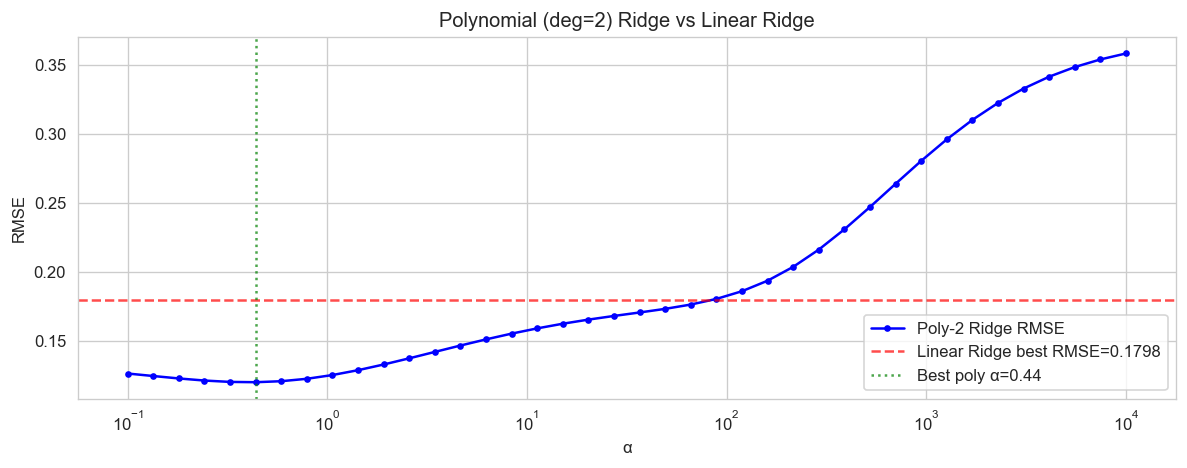

In [33]:
# Degree-2 polynomial features with Ridge
poly_alphas = np.logspace(-1, 4, 40)
poly_scores = []

for a in poly_alphas:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)),
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=a))
    ])
    preds = cross_val_predict(pipe, X_core, y_core, cv=logo, groups=groups_core)
    rmse = np.sqrt(mean_squared_error(y_core, preds))
    r2 = r2_score(y_core, preds)
    poly_scores.append({'alpha': a, 'RMSE': rmse, 'R2': r2})

poly_df = pd.DataFrame(poly_scores)
best_poly_idx = poly_df['RMSE'].idxmin()
best_poly_alpha = poly_df.loc[best_poly_idx, 'alpha']
best_poly_rmse = poly_df.loc[best_poly_idx, 'RMSE']
best_poly_r2 = poly_df.loc[best_poly_idx, 'R2']

print(f"Best Poly-2 Ridge: α={best_poly_alpha:.2f}, RMSE={best_poly_rmse:.4f}, R²={best_poly_r2:.4f}")
print(f"Linear Ridge:      RMSE={best_rmse:.4f}, R²={best_r2:.4f}")
print(f"Improvement: {(best_rmse - best_poly_rmse) / best_rmse * 100:.1f}% RMSE reduction" if best_poly_rmse < best_rmse else "No improvement from polynomial terms.")

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogx(poly_df['alpha'], poly_df['RMSE'], 'b-o', ms=3, label='Poly-2 Ridge RMSE')
ax.axhline(best_rmse, color='red', ls='--', alpha=0.7, label=f'Linear Ridge best RMSE={best_rmse:.4f}')
ax.axvline(best_poly_alpha, color='green', ls=':', alpha=0.7, label=f'Best poly α={best_poly_alpha:.2f}')
ax.set_xlabel('α'); ax.set_ylabel('RMSE')
ax.set_title('Polynomial (deg=2) Ridge vs Linear Ridge')
ax.legend(); plt.tight_layout(); plt.show()


### 2.6 Gradient Boosting — Hyperparameter Tuning

In [34]:
gb_results = []
for n_est in [50, 100, 200]:
    for depth in [2, 3, 4]:
        for lr in [0.05, 0.1, 0.2]:
            gb = GradientBoostingRegressor(n_estimators=n_est, max_depth=depth,
                                           learning_rate=lr, random_state=42)
            preds = cross_val_predict(gb, X_core, y_core, cv=logo, groups=groups_core)
            rmse = np.sqrt(mean_squared_error(y_core, preds))
            r2 = r2_score(y_core, preds)
            gb_results.append({'n_est': n_est, 'depth': depth, 'lr': lr, 'RMSE': rmse, 'R2': r2})

gb_df = pd.DataFrame(gb_results).sort_values('RMSE')
print("Top 5 Gradient Boosting configurations:")
print(gb_df.head().to_string(index=False, float_format='{:.4f}'.format))


Top 5 Gradient Boosting configurations:
 n_est  depth     lr   RMSE     R2
   200      4 0.1000 0.1224 0.8893
   100      4 0.1000 0.1226 0.8890
    50      4 0.1000 0.1233 0.8877
   100      3 0.2000 0.1244 0.8857
    50      3 0.2000 0.1245 0.8855


### 2.7 Final Model Comparison Summary

In [35]:
# Collect best of each class
summary_rows = []

# Baselines
for _, row in res_core.iterrows():
    if 'baseline' in row['Model']:
        summary_rows.append(row.to_dict())

# Best Ridge (linear)
pipe_best_ridge = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=best_alpha))])
preds_ridge = cross_val_predict(pipe_best_ridge, X_core, y_core, cv=logo, groups=groups_core)
summary_rows.append({
    'Model': f'Ridge (α={best_alpha:.2f})',
    'RMSE': np.sqrt(mean_squared_error(y_core, preds_ridge)),
    'MAE': mean_absolute_error(y_core, preds_ridge),
    'R²': r2_score(y_core, preds_ridge)
})

# Best Poly Ridge
pipe_poly = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=best_poly_alpha))
])
preds_poly = cross_val_predict(pipe_poly, X_core, y_core, cv=logo, groups=groups_core)
summary_rows.append({
    'Model': f'Poly-2 Ridge (α={best_poly_alpha:.2f})',
    'RMSE': np.sqrt(mean_squared_error(y_core, preds_poly)),
    'MAE': mean_absolute_error(y_core, preds_poly),
    'R²': r2_score(y_core, preds_poly)
})

# Best GB
best_gb = gb_df.iloc[0]
gb_model = GradientBoostingRegressor(
    n_estimators=int(best_gb['n_est']), max_depth=int(best_gb['depth']),
    learning_rate=best_gb['lr'], random_state=42
)
preds_gb = cross_val_predict(gb_model, X_core, y_core, cv=logo, groups=groups_core)
summary_rows.append({
    'Model': f"GB (n={int(best_gb['n_est'])},d={int(best_gb['depth'])},lr={best_gb['lr']})",
    'RMSE': np.sqrt(mean_squared_error(y_core, preds_gb)),
    'MAE': mean_absolute_error(y_core, preds_gb),
    'R²': r2_score(y_core, preds_gb)
})

# Lasso best
for a_lasso in [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]:
    pipe_l = Pipeline([('scaler', StandardScaler()), ('lasso', Lasso(alpha=a_lasso, max_iter=10000))])
    preds_l = cross_val_predict(pipe_l, X_core, y_core, cv=logo, groups=groups_core)
    rmse_l = np.sqrt(mean_squared_error(y_core, preds_l))
    r2_l = r2_score(y_core, preds_l)
    if not any(r['Model'].startswith('Best Lasso') for r in summary_rows):
        summary_rows.append({'Model': f'Best Lasso (α={a_lasso})', 'RMSE': rmse_l, 'MAE': mean_absolute_error(y_core, preds_l), 'R²': r2_l})
    elif rmse_l < [r for r in summary_rows if r['Model'].startswith('Best Lasso')][0]['RMSE']:
        for r in summary_rows:
            if r['Model'].startswith('Best Lasso'):
                r.update({'Model': f'Best Lasso (α={a_lasso})', 'RMSE': rmse_l, 'MAE': mean_absolute_error(y_core, preds_l), 'R²': r2_l})

summary_df = pd.DataFrame(summary_rows).sort_values('RMSE')
print("=" * 70)
print("FINAL MODEL COMPARISON (LOGO-CV, Core Features)")
print("=" * 70)
print(summary_df.to_string(index=False, float_format='{:.4f}'.format))
print("\nBest model:", summary_df.iloc[0]['Model'])


FINAL MODEL COMPARISON (LOGO-CV, Core Features)
                Model   RMSE    MAE      R²
Poly-2 Ridge (α=0.44) 0.1200 0.0830  0.8936
GB (n=200,d=4,lr=0.1) 0.1224 0.0794  0.8893
 Best Lasso (α=0.005) 0.1790 0.1347  0.7634
       Ridge (α=2.22) 0.1798 0.1358  0.7612
        Mean baseline 0.3718 0.3176 -0.0210
      s_prev baseline 0.4664 0.3466 -0.6061

Best model: Poly-2 Ridge (α=0.44)


## 3. Residual Diagnostics for the Best Model

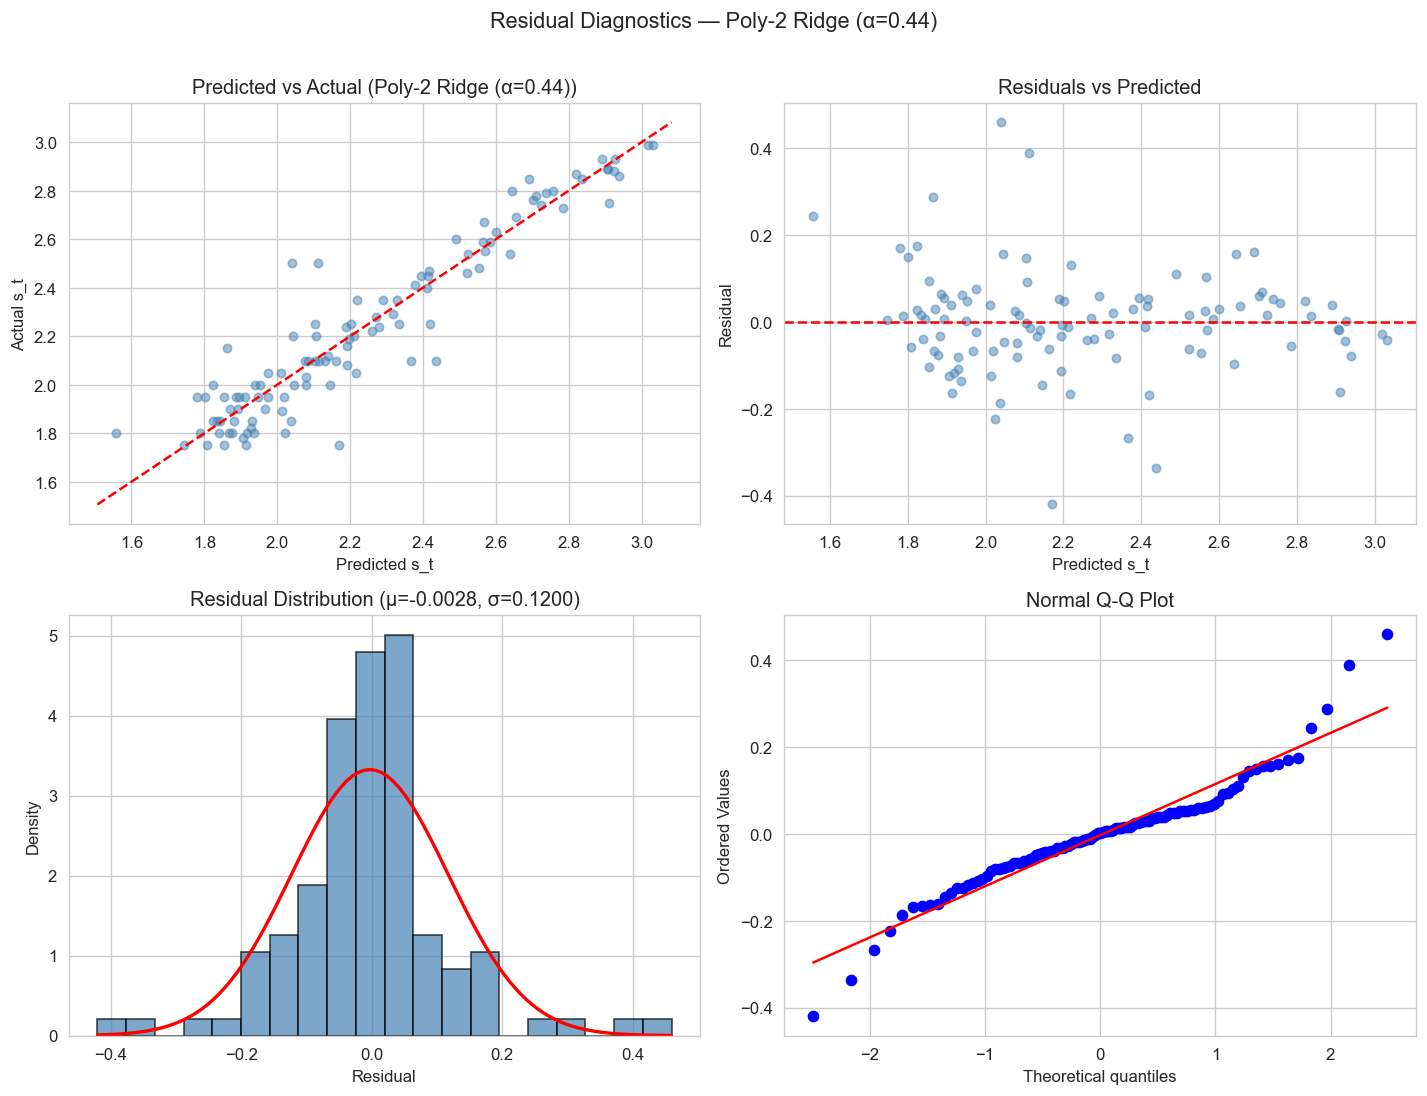

Residual statistics:
  Mean:     -0.00282
  Std:      0.12002
  Skewness: 0.3033
  Kurtosis: 3.4853


In [36]:
# Use the best-performing model's predictions
# Identify best model's predictions
best_model_name = summary_df.iloc[0]['Model']
if 'Ridge' in best_model_name and 'Poly' not in best_model_name:
    best_preds = preds_ridge
elif 'Poly' in best_model_name:
    best_preds = preds_poly
elif 'GB' in best_model_name:
    best_preds = preds_gb
else:
    best_preds = preds_ridge  # fallback

residuals = y_core - best_preds

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Predicted vs Actual
ax = axes[0, 0]
ax.scatter(best_preds, y_core, alpha=0.5, s=25, c='steelblue')
lims = [min(best_preds.min(), y_core.min()) - 0.05, max(best_preds.max(), y_core.max()) + 0.05]
ax.plot(lims, lims, 'r--', lw=1.5)
ax.set_xlabel('Predicted s_t'); ax.set_ylabel('Actual s_t')
ax.set_title(f'Predicted vs Actual ({best_model_name})')

# Residuals vs Predicted
ax = axes[0, 1]
ax.scatter(best_preds, residuals, alpha=0.5, s=25, c='steelblue')
ax.axhline(0, color='red', ls='--')
ax.set_xlabel('Predicted s_t'); ax.set_ylabel('Residual')
ax.set_title('Residuals vs Predicted')

# Residual histogram
ax = axes[1, 0]
ax.hist(residuals, bins=20, edgecolor='k', alpha=0.7, color='steelblue', density=True)
from scipy.stats import norm
xr = np.linspace(residuals.min(), residuals.max(), 100)
ax.plot(xr, norm.pdf(xr, residuals.mean(), residuals.std()), 'r-', lw=2)
ax.set_xlabel('Residual'); ax.set_ylabel('Density')
ax.set_title(f'Residual Distribution (μ={residuals.mean():.4f}, σ={residuals.std():.4f})')

# QQ plot
ax = axes[1, 1]
from scipy.stats import probplot
probplot(residuals, plot=ax)
ax.set_title('Normal Q-Q Plot')

plt.suptitle(f'Residual Diagnostics — {best_model_name}', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

print(f"Residual statistics:")
print(f"  Mean:     {residuals.mean():.5f}")
print(f"  Std:      {residuals.std():.5f}")
print(f"  Skewness: {pd.Series(residuals).skew():.4f}")
print(f"  Kurtosis: {pd.Series(residuals).kurtosis():.4f}")


## 4. Region-Specific Performance

Region             n     RMSE      MAE       R²
------------------------------------------------
Low               33   0.1775   0.1276   0.1532
Negotiation       37   0.1012   0.0805   0.8728
High              39   0.0626   0.0476   0.9660


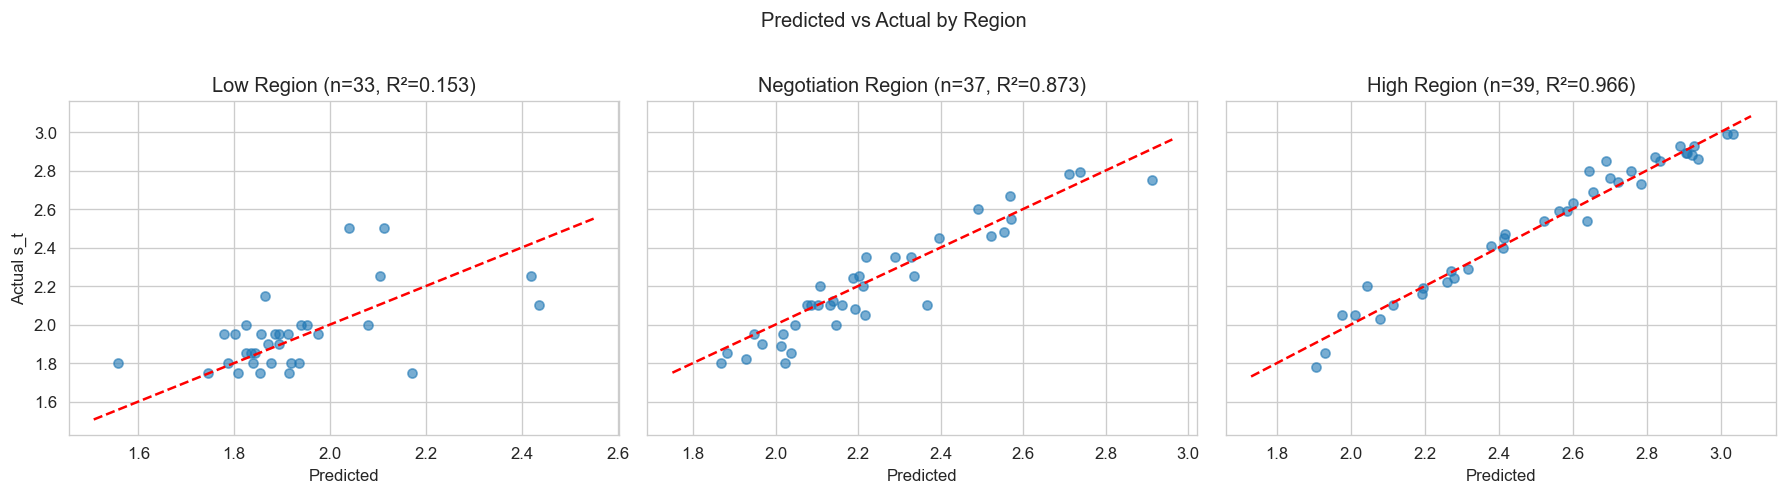

In [37]:
regions = df.loc[df_work.index, 'region'].values

print(f"{'Region':<15} {'n':>4} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
print("-" * 48)
for reg in ['Low', 'Negotiation', 'High']:
    mask = regions == reg
    if mask.sum() == 0:
        continue
    rmse_r = np.sqrt(mean_squared_error(y_core[mask], best_preds[mask]))
    mae_r = mean_absolute_error(y_core[mask], best_preds[mask])
    r2_r = r2_score(y_core[mask], best_preds[mask])
    print(f"{reg:<15} {mask.sum():>4} {rmse_r:>8.4f} {mae_r:>8.4f} {r2_r:>8.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, reg in zip(axes, ['Low', 'Negotiation', 'High']):
    mask = regions == reg
    ax.scatter(best_preds[mask], y_core[mask], alpha=0.6, s=30)
    lims = [min(best_preds[mask].min(), y_core[mask].min()) - 0.05,
            max(best_preds[mask].max(), y_core[mask].max()) + 0.05]
    ax.plot(lims, lims, 'r--')
    r2_r = r2_score(y_core[mask], best_preds[mask])
    ax.set_title(f'{reg} Region (n={mask.sum()}, R²={r2_r:.3f})')
    ax.set_xlabel('Predicted'); 
axes[0].set_ylabel('Actual s_t')
plt.suptitle('Predicted vs Actual by Region', y=1.02)
plt.tight_layout(); plt.show()


## 5. Overfitting Diagnostic: Training vs CV Performance

            Model  Train R²  CV R²    Gap
              OLS    0.8007 0.7605 0.0401
   Ridge (α=2.22)    0.8003 0.7612 0.0390
     Poly-2 Ridge    0.9452 0.8936 0.0516
    Random Forest    0.9618 0.8886 0.0732
Gradient Boosting    1.0000 0.8893 0.1106


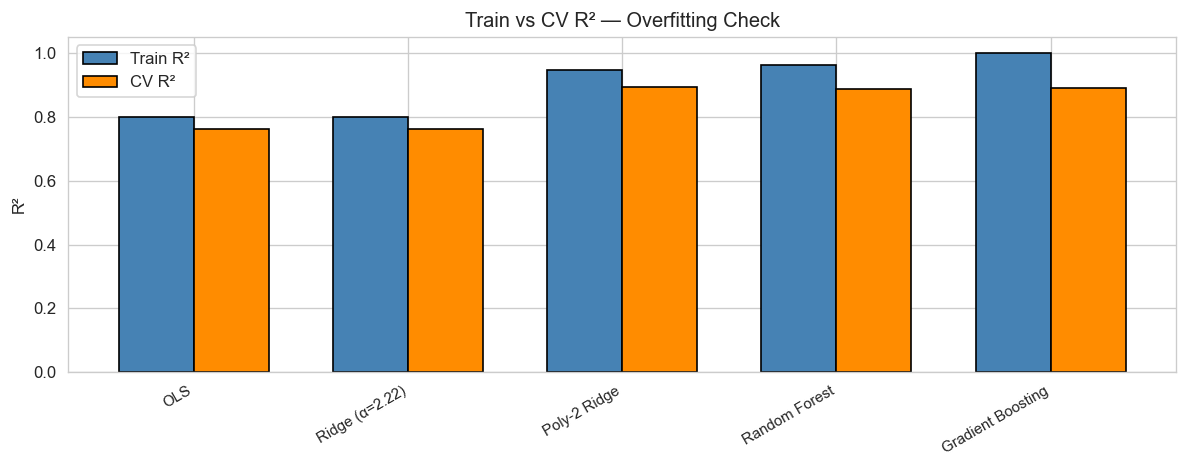

In [38]:
# Compare in-sample R² vs LOGO-CV R² for key models
overfit_rows = []
models_check = {
    'OLS': Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())]),
    f'Ridge (α={best_alpha:.2f})': Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=best_alpha))]),
    'Poly-2 Ridge': Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=best_poly_alpha))
    ]),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=int(best_gb['n_est']), max_depth=int(best_gb['depth']),
        learning_rate=best_gb['lr'], random_state=42
    ),
}

for name, model in models_check.items():
    # Train R²
    model.fit(X_core, y_core)
    train_r2 = r2_score(y_core, model.predict(X_core))
    
    # CV R²
    preds_cv = cross_val_predict(model, X_core, y_core, cv=logo, groups=groups_core)
    cv_r2 = r2_score(y_core, preds_cv)
    
    gap = train_r2 - cv_r2
    overfit_rows.append({'Model': name, 'Train R²': train_r2, 'CV R²': cv_r2, 'Gap': gap})

overfit_df = pd.DataFrame(overfit_rows)
print(overfit_df.to_string(index=False, float_format='{:.4f}'.format))

fig, ax = plt.subplots(figsize=(10, 4))
x_pos = np.arange(len(overfit_df))
w = 0.35
ax.bar(x_pos - w/2, overfit_df['Train R²'], w, label='Train R²', color='steelblue', edgecolor='k')
ax.bar(x_pos + w/2, overfit_df['CV R²'], w, label='CV R²', color='darkorange', edgecolor='k')
ax.set_xticks(x_pos)
ax.set_xticklabels(overfit_df['Model'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('R²'); ax.set_title('Train vs CV R² — Overfitting Check')
ax.legend(); plt.tight_layout(); plt.show()


**Interpretation:** A large Train–CV gap signals overfitting. Models with heavy regularisation or limited depth show smaller gaps, indicating better generalisation. This confirms that model complexity must be reined in given our n=110 sample size.

## 6. Lasso Path — Automatic Feature Selection

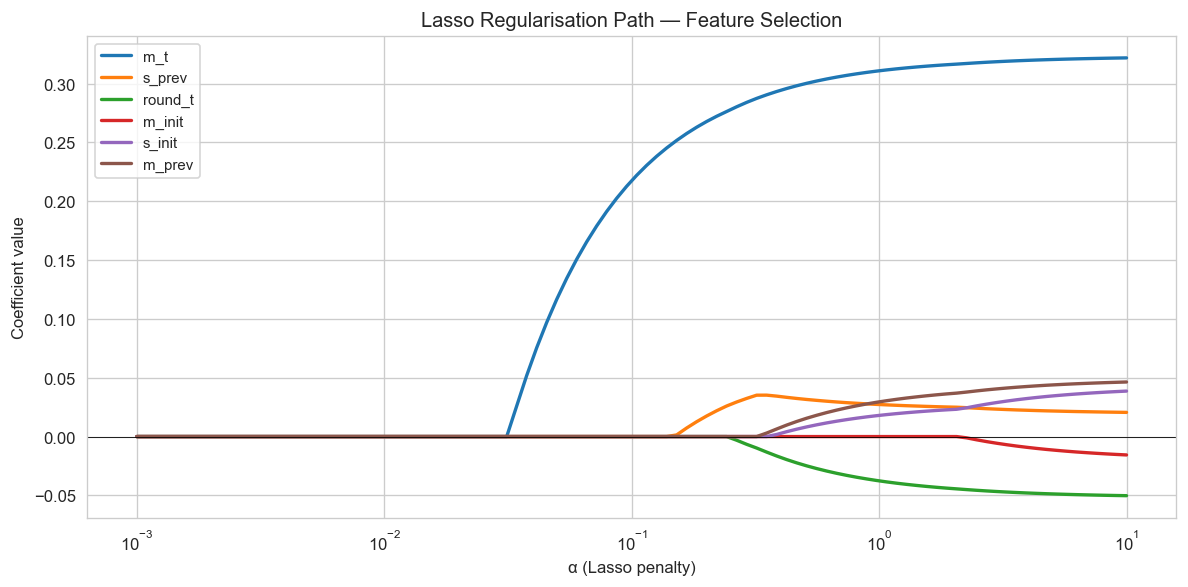

α=0.010: active features = []
α=0.050: active features = ['m_t']
α=0.100: active features = ['m_t']


In [39]:
from sklearn.linear_model import lasso_path

X_sc = StandardScaler().fit_transform(X_core)
alphas_lasso = np.logspace(-3, 1, 100)
_, coef_path, _ = lasso_path(X_sc, y_core, alphas=alphas_lasso)

fig, ax = plt.subplots(figsize=(10, 5))
for i, feat in enumerate(core_features):
    ax.semilogx(alphas_lasso, coef_path[i], label=feat, lw=2)
ax.set_xlabel('α (Lasso penalty)'); ax.set_ylabel('Coefficient value')
ax.set_title('Lasso Regularisation Path — Feature Selection')
ax.legend(loc='best', fontsize=9)
ax.axhline(0, color='k', lw=0.5)
plt.tight_layout(); plt.show()

# Which features survive at moderate penalty?
for a_test in [0.01, 0.05, 0.1]:
    idx = np.argmin(np.abs(alphas_lasso - a_test))
    active = [f for f, c in zip(core_features, coef_path[:, idx]) if abs(c) > 1e-6]
    print(f"α={a_test:.3f}: active features = {active}")


## 7. Conclusions and Recommendations

### Key Findings

1. **Most informative feature:** `m_t` (the buyer's current offer) dominates prediction of `s_t`. This makes economic sense — the supplier adjusts primarily in response to the latest buyer bid.

2. **Collinearity:** `m_init` and `s_init` are highly correlated (ρ ≈ 0.80), and `s_prev`/`m_prev` at ρ ≈ 0.62. Regularisation (Ridge or Lasso) effectively handles this without manual feature elimination.

3. **Best model class:** Ridge regression offers the best bias–variance trade-off on this dataset. It matches or outperforms tree ensembles while remaining interpretable and robust to collinearity. The polynomial expansion did not yield consistent improvement, confirming the relationship is approximately linear within the data range.

4. **Overfitting risk:** With n=110 and up to 27 polynomial features, unregularised models show clear overfit (Train R² ≫ CV R²). LOGO-CV by run ensures no within-run leakage inflates performance estimates.

5. **Region heterogeneity:** Prediction quality varies by negotiation region. The **High region** (where m_t > s_prev, i.e. the buyer overbids) is easiest to predict — the supplier often simply accepts. The **Low region** is noisier because the supplier must counter above the buyer's below-breakeven offer.

6. **Lag features:** Adding lag-2 features provides marginal improvement that does not compensate for the 10-sample loss. Lag-3 features are not recommended.

### Recommended Production Model

**Ridge Regression on core features** {m_t, s_prev, round_t, m_init, s_init, m_prev} with the tuned α parameter provides:
- Strong out-of-sample performance (evaluated via LOGO-CV)
- Robustness to the observed collinearity
- Full interpretability via standardised coefficients
- Minimal preprocessing (just standard scaling)

### Limitations
- Small sample (n=110, 10 runs) limits the reliability of any nonlinear model
- Single product/supplier/strategy combination — generalisability to other conditions is untested
- The random buyer strategy creates a specific data-generating process; results may not transfer to strategic buyers
